# French Motor TPL — Pricing Pipeline

End-to-end actuarial pricing using GLMs:
- **Frequency model**: Poisson GLM with `Exposure` as offset
- **Severity model**: Gamma GLM on positive claim amounts
- **Pure premium** = E[Frequency] × E[Severity]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("Setup ✓")

Matplotlib is building the font cache; this may take a moment.


Setup ✓


In [3]:
freq = pd.read_csv("../data/freMTPL2freq.csv")
sev = pd.read_csv("../data/freMTPL2sev.csv")

# Total claim amount per policy (sum across multiple claims)
sev_agg = sev.groupby("IDpol")["ClaimAmount"].sum().reset_index()
sev_agg.columns = ["IDpol", "TotalClaimAmount"]

# Merge severity into the policy-level table
df = freq.merge(sev_agg, on="IDpol", how="left")
df["TotalClaimAmount"] = df["TotalClaimAmount"].fillna(0)

# Data quality caps
df["Exposure"] = df["Exposure"].clip(upper=1)
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)

print(f"Policies: {len(df):,}")
print(f"Claims: {df['ClaimNb'].sum():,}")
print(f"Exposure-years: {df['Exposure'].sum():,.0f}")

Policies: 678,013
Claims: 36,056
Exposure-years: 358,360


## Train/test split

In [4]:
train, test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train):,} | Test: {len(test):,}")

Train: 542,410 | Test: 135,603


## Frequency Model — Poisson GLM

Predicts expected number of claims per policy/year.  
Log-link with `log(Exposure)` as offset (standard actuarial practice).

In [5]:
formula_freq = (
    "ClaimNb ~ DrivAge + VehAge + VehPower + BonusMalus "
    "+ C(VehBrand) + C(VehGas) + C(Area) + np.log(Density)"
)

freq_model = smf.glm(
    formula=formula_freq,
    data=train,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=np.log(train["Exposure"]),
).fit()

print(freq_model.summary().tables[0])
print(f"\nPseudo R²: {1 - freq_model.deviance/freq_model.null_deviance:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542388
Model Family:                 Poisson   Df Model:                           21
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1434e+05
Date:                Sat, 09 May 2026   Deviance:                   1.7329e+05
Time:                        21:46:45   Pearson chi2:                 1.36e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01050
Covariance Type:            nonrobust                                         

Pseudo R²: 0.0320


In [6]:
test_pred_freq = freq_model.predict(test, offset=np.log(test["Exposure"]))

mae = mean_absolute_error(test["ClaimNb"], test_pred_freq)
total_pred = test_pred_freq.sum()
total_actual = test["ClaimNb"].sum()

print(f"Test MAE: {mae:.4f}")
print(f"Predicted total claims: {total_pred:,.0f}")
print(f"Actual total claims:    {total_actual:,.0f}")
print(f"Bias: {(total_pred/total_actual - 1)*100:+.2f}%")

Test MAE: 0.0989
Predicted total claims: 7,189
Actual total claims:    7,239
Bias: -0.69%


## Severity Model — Gamma GLM

Predicts expected claim amount per claim.  
Fitted only on policies with `ClaimNb > 0`. Top 0.5% capped for stability.

In [7]:
train_sev = train[train["ClaimNb"] > 0].copy()
train_sev["AvgClaim"] = train_sev["TotalClaimAmount"] / train_sev["ClaimNb"]

upper = train_sev["AvgClaim"].quantile(0.995)
train_sev = train_sev[train_sev["AvgClaim"] <= upper]

formula_sev = (
    "AvgClaim ~ DrivAge + VehAge + VehPower + BonusMalus "
    "+ C(VehBrand) + C(VehGas) + C(Area)"
)

sev_model = smf.glm(
    formula=formula_sev,
    data=train_sev,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

print(sev_model.summary().tables[0])
print(f"\nMean predicted severity: €{sev_model.predict(train_sev).mean():,.2f}")
print(f"Mean actual severity:    €{train_sev['AvgClaim'].mean():,.2f}")

C:\Users\leona\projetos\insurance-pricing-glm\venv\Lib\site-packages\statsmodels\genmod\families\family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
C:\Users\leona\projetos\insurance-pricing-glm\venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


                 Generalized Linear Model Regression Results                  
Dep. Variable:               AvgClaim   No. Observations:                27077
Model:                            GLM   Df Residuals:                    27056
Model Family:                   Gamma   Df Model:                           20
Link Function:                    Log   Scale:                          2.9026
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Sat, 09 May 2026   Deviance:                   5.3859e+05
Time:                        21:46:51   Pearson chi2:                 7.85e+04
No. Iterations:                    20   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         

Mean predicted severity: €1,069.81
Mean actual severity:    €1,064.54


## Pure Premium

`Pure Premium = E[Frequency] × E[Severity]`

Pure premium summary (€/year):
count    135603.00
mean        115.09
std          86.72
min           4.23
25%          71.60
50%          91.45
75%         126.71
max       10899.43
Name: PurePremium, dtype: float64


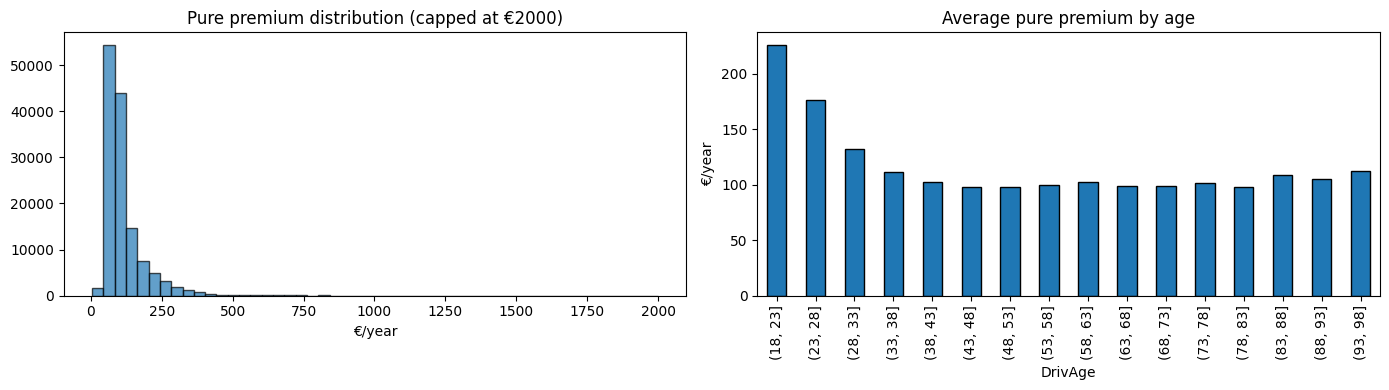

In [8]:
test_pred_freq_per_year = freq_model.predict(test, offset=np.zeros(len(test)))
test_pred_sev = sev_model.predict(test)
test["PurePremium"] = test_pred_freq_per_year * test_pred_sev

print("Pure premium summary (€/year):")
print(test["PurePremium"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(test["PurePremium"].clip(upper=2000), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title("Pure premium distribution (capped at €2000)")
axes[0].set_xlabel("€/year")

premium_by_age = test.groupby(pd.cut(test["DrivAge"], bins=range(18, 100, 5)), observed=True)["PurePremium"].mean()
premium_by_age.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title("Average pure premium by age")
axes[1].set_ylabel("€/year")
plt.tight_layout()
plt.show()

In [9]:
import pickle
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

with open(models_dir / "freq_model.pkl", "wb") as f:
    pickle.dump(freq_model, f)

with open(models_dir / "sev_model.pkl", "wb") as f:
    pickle.dump(sev_model, f)

print(f"Models saved to {models_dir.resolve()}/")

Models saved to C:\Users\leona\projetos\insurance-pricing-glm\models/


## Summary

| Component | Model | Distribution |
|---|---|---|
| Frequency | Poisson GLM | Log-link with `log(Exposure)` offset |
| Severity | Gamma GLM | Log-link, fitted on positive claims |
| Pure Premium | Combined | Frequency × Severity |

Models are saved to `models/` and ready to be served via `src/api/main.py`.